In [5]:
import pandas as pd
import glob

file_path = r"C:\Users\hp\Downloads\Train_data.csv\Train_data.csv.csv"
data = pd.read_csv(file_path)

print(data.head())

   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_srv_count  \
0               0       0    0  ...                  25   
1               0       0    0  ...                   1   
2               0       0    0  ...                  26   
3               0       0    0  ...                 255   
4               0       0    0  ...                 255   

   dst_host_same_srv_rate  dst_host_diff_srv_rate  \
0                    0.17                    0.03   
1                    0.00                    0.60   
2                    0.10                    0.05   


In [7]:
import pandas as pd
import glob

file_path = r"C:\Users\hp\Downloads\Train_data.csv\Train_data.csv.csv"
data = pd.read_csv(file_path)

print(data.head())

   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_srv_count  \
0               0       0    0  ...                  25   
1               0       0    0  ...                   1   
2               0       0    0  ...                  26   
3               0       0    0  ...                 255   
4               0       0    0  ...                 255   

   dst_host_same_srv_rate  dst_host_diff_srv_rate  \
0                    0.17                    0.03   
1                    0.00                    0.60   
2                    0.10                    0.05   


In [8]:
print("Rows and columns:", data.shape)

print("\nColumn names:")
print(data.columns.tolist())


Rows and columns: (25192, 42)

Column names:
['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'class']


In [9]:
# Separate features and target

X = data.drop("class", axis=1)
y = data["class"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget values:")
print(y.value_counts())

Features shape: (25192, 41)
Target shape: (25192,)

Target values:
class
normal     13449
anomaly    11743
Name: count, dtype: int64


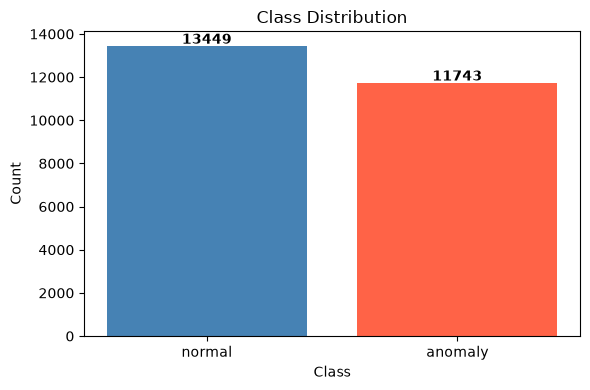

Missing values per column:
No missing values found.

Basic statistics for numeric features:
           duration     src_bytes     dst_bytes         count     srv_count
count  25192.000000  2.519200e+04  2.519200e+04  25192.000000  25192.000000
mean     305.054104  2.433063e+04  3.491847e+03     84.591180     27.698754
std     2686.555640  2.410805e+06  8.883072e+04    114.673451     72.468242
min        0.000000  0.000000e+00  0.000000e+00      1.000000      1.000000
25%        0.000000  0.000000e+00  0.000000e+00      2.000000      2.000000
50%        0.000000  4.400000e+01  0.000000e+00     14.000000      8.000000
75%        0.000000  2.790000e+02  5.302500e+02    144.000000     18.000000
max    42862.000000  3.817091e+08  5.151385e+06    511.000000    511.000000


In [10]:
# --- EDA: Class distribution & missing-value check ---
import matplotlib.pyplot as plt

# Class distribution bar chart
class_counts = y.value_counts()
plt.figure(figsize=(6, 4))
plt.bar(class_counts.index, class_counts.values, color=["steelblue", "tomato"])
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 100, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

# Missing value check
missing = data.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.any() else "No missing values found.")

# Numeric feature summary for a few key columns
print("\nBasic statistics for numeric features:")
print(data[['duration', 'src_bytes', 'dst_bytes', 'count', 'srv_count']].describe())

In [11]:
# Convert categorical columns into numbers

X = pd.get_dummies(X)

print("New feature shape:", X.shape)
print(X.head())

New feature shape: (25192, 118)
   duration  src_bytes  dst_bytes  land  wrong_fragment  urgent  hot  \
0         0        491          0     0               0       0    0   
1         0        146          0     0               0       0    0   
2         0          0          0     0               0       0    0   
3         0        232       8153     0               0       0    0   
4         0        199        420     0               0       0    0   

   num_failed_logins  logged_in  num_compromised  ...  flag_REJ  flag_RSTO  \
0                  0          0                0  ...     False      False   
1                  0          0                0  ...     False      False   
2                  0          0                0  ...     False      False   
3                  0          1                0  ...     False      False   
4                  0          1                0  ...     False      False   

   flag_RSTOS0  flag_RSTR  flag_S0  flag_S1  flag_S2  flag_S3  fla

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (20153, 118)
Testing data: (5039, 118)


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (20153, 118)
X_test shape: (5039, 118)


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9724151617384401

Classification Report:
              precision    recall  f1-score   support

     anomaly       0.98      0.96      0.97      2349
      normal       0.97      0.98      0.97      2690

    accuracy                           0.97      5039
   macro avg       0.97      0.97      0.97      5039
weighted avg       0.97      0.97      0.97      5039



Confusion Matrix:
[[2266   83]
 [  56 2634]]


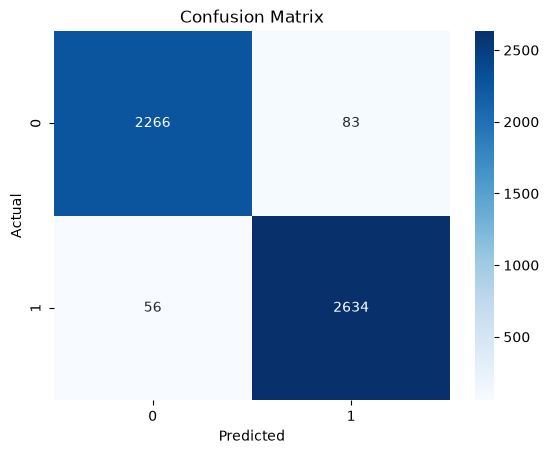

In [16]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# NOTE: model.predict() already returns string labels ("anomaly" / "normal")
# because y_train is a string Series — no int->string conversion needed.
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label="anomaly")
recall = recall_score(y_test, y_pred, pos_label="anomaly")
f1 = f1_score(y_test, y_pred, pos_label="anomaly")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy : 0.9724151617384401
Precision: 0.9758828596037898
Recall   : 0.9646658152405279
F1 Score : 0.9702419182187968

Classification Report:
              precision    recall  f1-score   support

     anomaly       0.98      0.96      0.97      2349
      normal       0.97      0.98      0.97      2690

    accuracy                           0.97      5039
   macro avg       0.97      0.97      0.97      5039
weighted avg       0.97      0.97      0.97      5039



In [18]:
# --- Random Forest: second model for comparison ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

=== Random Forest ===
Accuracy: 0.9978170271879341

Classification Report:
              precision    recall  f1-score   support

     anomaly       1.00      1.00      1.00      2349
      normal       1.00      1.00      1.00      2690

    accuracy                           1.00      5039
   macro avg       1.00      1.00      1.00      5039
weighted avg       1.00      1.00      1.00      5039



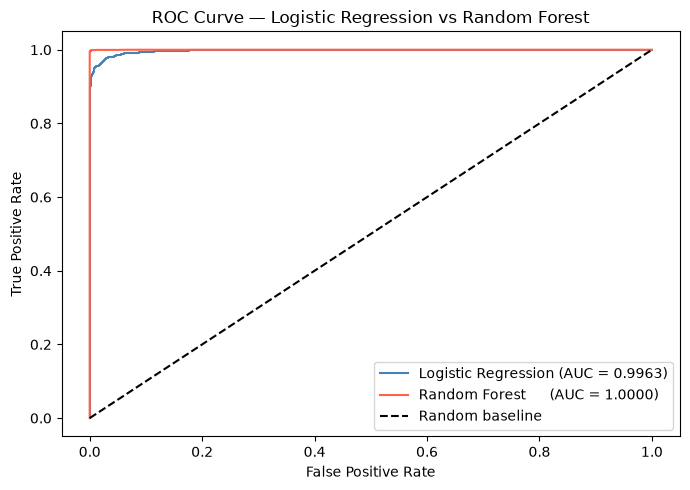

Logistic Regression AUC: 0.9963
Random Forest AUC      : 1.0000


In [19]:
# --- ROC Curve + AUC for both models ---
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Logistic Regression probability scores
y_prob_lr = model.predict_proba(X_test)[:, 1]   # probability of "normal" (index 1)
# We need probability of the positive class (anomaly = index 0)
classes = list(model.classes_)
anomaly_idx_lr = classes.index("anomaly")
anomaly_idx_rf = list(rf_model.classes_).index("anomaly")

y_prob_lr = model.predict_proba(X_test)[:, anomaly_idx_lr]
y_prob_rf = rf_model.predict_proba(X_test)[:, anomaly_idx_rf]

# Binary labels for roc_curve (1 = anomaly, 0 = normal)
y_binary = (y_test == "anomaly").astype(int)

fpr_lr, tpr_lr, _ = roc_curve(y_binary, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_binary, y_prob_rf)

auc_lr = roc_auc_score(y_binary, y_prob_lr)
auc_rf = roc_auc_score(y_binary, y_prob_rf)

plt.figure(figsize=(7, 5))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.4f})", color="steelblue")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest      (AUC = {auc_rf:.4f})", color="tomato")
plt.plot([0, 1], [0, 1], 'k--', label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Logistic Regression vs Random Forest")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"Logistic Regression AUC: {auc_lr:.4f}")
print(f"Random Forest AUC      : {auc_rf:.4f}")

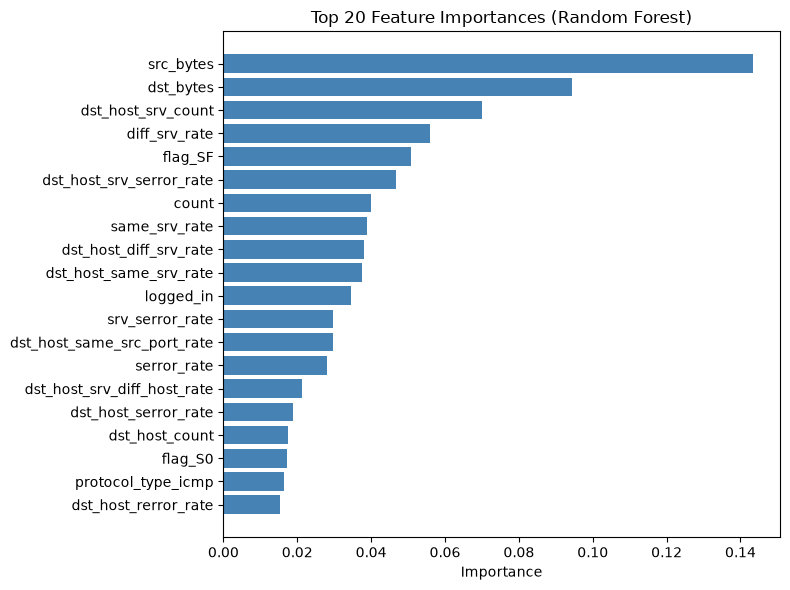

                    feature  importance
                  src_bytes    0.143521
                  dst_bytes    0.094291
         dst_host_srv_count    0.069985
              diff_srv_rate    0.055845
                    flag_SF    0.050755
   dst_host_srv_serror_rate    0.046639
                      count    0.040050
              same_srv_rate    0.038941
     dst_host_diff_srv_rate    0.038010
     dst_host_same_srv_rate    0.037602
                  logged_in    0.034589
            srv_serror_rate    0.029798
dst_host_same_src_port_rate    0.029691
                serror_rate    0.027932
dst_host_srv_diff_host_rate    0.021234
       dst_host_serror_rate    0.018726
             dst_host_count    0.017466
                    flag_S0    0.017288
         protocol_type_icmp    0.016538
       dst_host_rerror_rate    0.015320


In [20]:
# --- Feature Importance (top 20 features from Random Forest) ---
import pandas as pd
import matplotlib.pyplot as plt

# X was converted to numpy by StandardScaler; recover column names from the
# get_dummies step stored before scaling.
# We rebuild the column list from the dummies-expanded DataFrame.
# (X_train / X_test are numpy arrays at this point; feature names were in X before scaling)

# Re-derive feature names: re-run get_dummies on the original data (no side effects)
feature_names = pd.get_dummies(data.drop("class", axis=1)).columns.tolist()

importances = rf_model.feature_importances_
feat_df = pd.DataFrame({"feature": feature_names, "importance": importances})
feat_df = feat_df.sort_values("importance", ascending=False).head(20)

plt.figure(figsize=(8, 6))
plt.barh(feat_df["feature"][::-1], feat_df["importance"][::-1], color="steelblue")
plt.xlabel("Importance")
plt.title("Top 20 Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()

print(feat_df.to_string(index=False))

In [21]:
import joblib

joblib.dump(rf_model, "network_anomaly_rf_model.pkl")

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


In [22]:
# Test the model with one sample from the test data

sample = X_test[0].reshape(1, -1)

prediction = model.predict(sample)

# model.predict() returns string labels ("anomaly" / "normal"), not integers
if prediction[0] == "anomaly":
    print("Prediction: ANOMALY")
else:
    print("Prediction: NORMAL")

Prediction: ANOMALY


In [23]:
actual = y_test.iloc[0]

print("Actual:", actual)
# prediction[0] is already a string label
print("Predicted:", "anomaly" if prediction[0] == "anomaly" else "normal")

Actual: anomaly
Predicted: anomaly


In [24]:
predictions = model.predict(X_test[:10])

for i in range(10):
    actual = y_test.iloc[i]
    # predictions[i] is already a string label — use it directly
    predicted = predictions[i]

    print(f"Sample {i+1}: Actual = {actual}, Predicted = {predicted}")

Sample 1: Actual = anomaly, Predicted = anomaly
Sample 2: Actual = normal, Predicted = normal
Sample 3: Actual = anomaly, Predicted = anomaly
Sample 4: Actual = anomaly, Predicted = anomaly
Sample 5: Actual = normal, Predicted = normal
Sample 6: Actual = normal, Predicted = normal
Sample 7: Actual = normal, Predicted = normal
Sample 8: Actual = anomaly, Predicted = anomaly
Sample 9: Actual = anomaly, Predicted = anomaly
Sample 10: Actual = normal, Predicted = normal


In [25]:
def detect_intrusion(sample):
    prediction = model.predict(sample)
    # model.predict() returns string labels ("anomaly" / "normal")
    if prediction[0] == "anomaly":
        return "ANOMALY"
    else:
        return "NORMAL"


# Test the function
result = detect_intrusion(X_test[0].reshape(1, -1))

print("Network Traffic:", result)

Network Traffic: ANOMALY


In [31]:
# Test the intrusion detection system

sample = X_test[0].reshape(1, -1)

result = detect_intrusion(sample)

print("Network Traffic Result:", result)

Network Traffic Result: ANOMALY
